# 01 · Architecture tour

Neighborhood Watch turns five public data sources into a map, an area panel, a next-week forecast and
a chat agent for Chicago's 77 community areas. This notebook is the map of the territory: the layers,
what each pipeline notebook reads and writes, where the code lives, and how the app and the agent sit on
top. The later tutorials zoom into one piece each.

| # | Tutorial | What you'll see |
|---|---|---|
| 01 | Architecture tour | the layers, the table lineage (read straight from the code), the code layout |
| 02 | Ingestion and the medallion layers | SODA, why bronze is all strings, the stub newest day, silver |
| 03 | Trends and normals | the partial-month trap, windows, normal for this time of year, per-resident rates |
| 04 | Leading indicators | does 311 lead crime? demeaning, lagged correlations, the placebo |
| 05 | Next-week outlook | the seasonal bar, the forecast, the backtest, the leaderboard, adding a feature |
| 06 | Events look-ahead | observed vs. expected, Gamma-Poisson pooling, the real upcoming list |
| 07 | The agent and the app | tools, the tool-calling loop, the fake data layer, the app's routes |

Everything here runs locally; nothing needs a Databricks workspace.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent   # run from the repo root or tutorials/
sys.path[:0] = [str(ROOT), str(ROOT / "tutorials")]

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import _data
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e1e0d9", "axes.prop_cycle": plt.cycler(color=["#2a78d6", "#eb6834", "#1baf7a", "#898781"])})
pd.set_option("display.width", 160, "display.max_columns", 30)
print("data from:", _data.source())

import ast
import re

from IPython.display import SVG, display

data from: local exports


## The big picture

Read the diagram left to right: data flows from the **sources** through **bronze** (raw API rows),
**silver** (typed and cleaned) and **gold** (aggregates and model outputs), all Delta tables in Unity
Catalog, built by one nightly job. The **serving** layer is what the app touches at request time, and
the **analytics loop** at the bottom brings the app's own writes back into Unity Catalog.

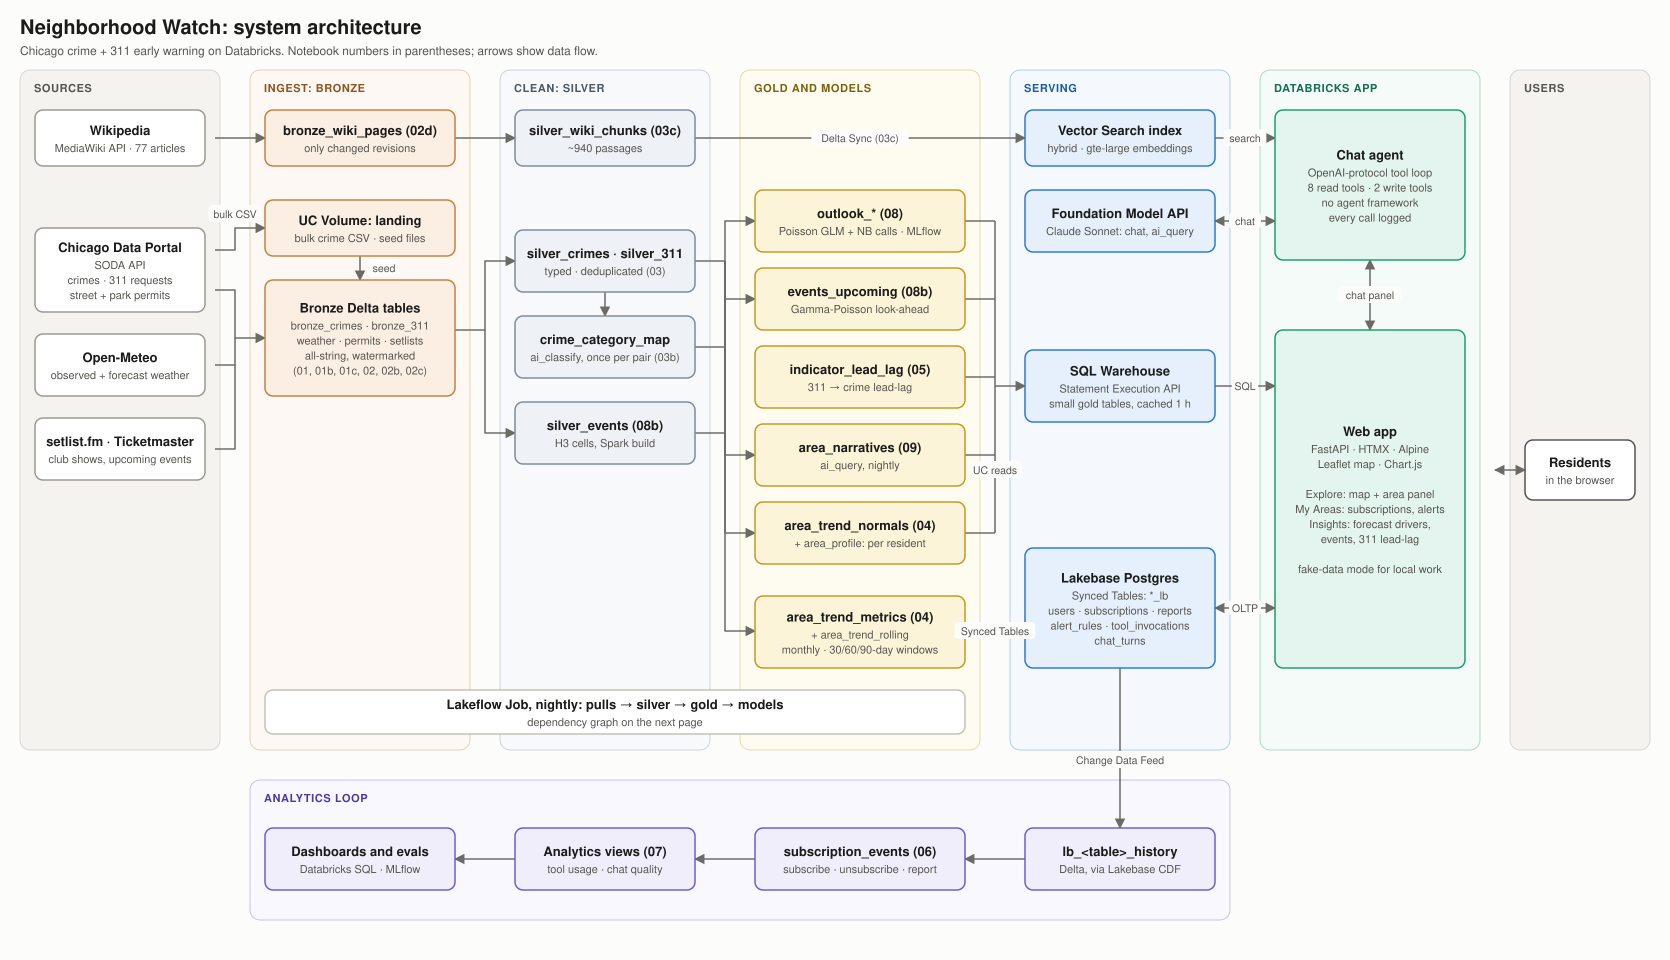

In [2]:
display(SVG(filename=str(ROOT / "docs/architecture/system.svg")))

Three things to notice:

- **Two serving paths for gold.** The trend tables the app reads on every click are synced into
  Lakebase (Postgres) as Synced Tables. The small nightly tables (normals, forecast, events, narratives)
  stay in Unity Catalog and are read through a SQL warehouse with a one-hour cache in the app. Postgres
  for the hot paths, no extra sync jobs for the cold ones.
- **The app writes to Postgres; analytics reads Delta.** Subscriptions, alert rules and chat logs
  live in Lakebase, and Change Data Feed copies every change back to Unity Catalog within seconds.
- **AI runs in the pipeline, not at read time** (except the chat agent): crime categories
  (`ai_classify`) and the area narratives (`ai_query`) are computed nightly, so the app reads finished
  rows.

## The pipeline, from the code itself

Rather than trust a hand-drawn diagram, rebuild the table lineage from the repo: the notebook table in
`docs/architecture.md` says what each notebook **writes**, and scanning each notebook's source for those
table names gives what it **reads**.

In [3]:
doc = (ROOT / "docs/architecture.md").read_text()
writes = {}
for line in doc.splitlines():
    m = re.match(r"\| `(\d\w+)` \| (.+?) \| (once|nightly) \|", line)
    if m:
        names = [n for n in re.findall(r"`([a-z0-9_]+)`", m.group(2)) if "_" in n and not n.startswith("ai_")]
        writes[m.group(1)] = (names, m.group(3))

writers = {}                     # table -> the notebooks that write it (bulk loads and nightly pulls can share one)
for nb, (ts, _) in writes.items():
    for t in ts:
        writers.setdefault(t, set()).add(nb)

rows = []
for nb, (ts, when) in writes.items():
    words = set(re.findall(r"[a-z0-9_]+", (ROOT / "notebooks" / f"{nb}.py").read_text()))
    reads = sorted(t for t in writers if t in words and t not in ts)
    cdf = sorted(w for w in words if w.startswith("lb_") and w.endswith("_history"))   # Lakebase CDF tables
    rows.append({"notebook": nb, "runs": when, "reads": ", ".join(reads + cdf), "writes": ", ".join(ts)})
lineage = pd.DataFrame(rows)
lineage.style.hide(axis="index")

notebook,runs,reads,writes
00_setup,once,,
01_bronze_bulk_load_crimes,once,,bronze_crimes
01b_bronze_bulk_load_311,once,,bronze_311
01c_seed_from_volume,once,,"bronze_weather_observed, bronze_weather_forecast, bronze_cdot_permits, bronze_park_permits, bronze_park_polygons, bronze_setlists, bronze_ticketmaster"
02_bronze_incremental,nightly,,"bronze_crimes, bronze_311"
02b_bronze_weather,nightly,,"bronze_weather_observed, bronze_weather_forecast"
02c_bronze_events,nightly,,"bronze_cdot_permits, bronze_park_permits, bronze_park_polygons, bronze_setlists, bronze_ticketmaster"
02d_bronze_wikipedia,nightly,,bronze_wiki_pages
03_silver_tables,nightly,"bronze_311, bronze_crimes","silver_crimes, silver_311"
03b_crime_categories,nightly,silver_crimes,crime_category_map


Turn that into a dependency graph: notebook B depends on notebook A when B reads something A writes.
Laying the nightly notebooks out by dependency depth gives the order the job runs them in.

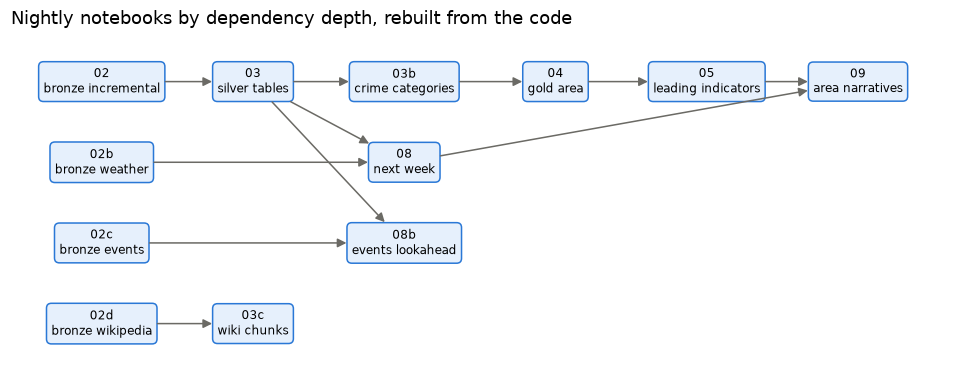

In [4]:
nightly = [nb for nb, (_, when) in writes.items() if when == "nightly"]
deps = {r.notebook: {w for t in r.reads.split(", ") for w in writers.get(t, ()) if w in nightly and w != r.notebook}
        for r in lineage.itertuples() if r.notebook in nightly}
def upstream(nb):                # everything nb depends on, directly or not
    return set().union(*({d} | upstream(d) for d in deps[nb])) if deps[nb] else set()

# Keep only direct edges: drop A -> C when C already depends on A through some B.
deps = {nb: {d for d in ds if not any(d in upstream(o) for o in ds - {d})} for nb, ds in deps.items()}

level = {}
def depth(nb):
    if nb not in level:
        level[nb] = 1 + max((depth(d) for d in deps[nb]), default=-1)
    return level[nb]
for nb in nightly:
    depth(nb)

# x = depth; y = the average height of a notebook's inputs, nudged down when two collide
pos = {}
for lv in range(max(level.values()) + 1):
    col = [nb for nb in nightly if level[nb] == lv]
    bary = {nb: np.mean([pos[d][1] for d in deps[nb]]) if deps[nb] else -nightly.index(nb) for nb in col}
    y_prev = 1
    for nb in sorted(col, key=bary.get, reverse=True):
        y_prev = min(round(bary[nb]), y_prev - 1)
        pos[nb] = (lv, y_prev)

fig, ax = plt.subplots(figsize=(11, 4))
ax.set_xlim(-0.6, max(level.values()) + 0.6)
ax.set_ylim(min(y for _, y in pos.values()) - 0.6, 0.6)
ax.axis("off")
boxes = {nb: ax.text(x, y, nb.split("_")[0] + "\n" + " ".join(nb.split("_")[1:3]), ha="center", va="center",
                     fontsize=8, zorder=2, bbox=dict(boxstyle="round,pad=0.4", fc="#e6f0fc", ec="#2a78d6"))
         for nb, (x, y) in pos.items()}
fig.canvas.draw()                # size the boxes, so the arrows can stop at their edges
for nb in nightly:
    for d in deps[nb]:
        ax.annotate("", pos[nb], pos[d], zorder=3, arrowprops=dict(
            arrowstyle="-|>", mutation_scale=12, color="#6b6a65", shrinkA=0, shrinkB=0,
            patchA=boxes[d].get_bbox_patch(), patchB=boxes[nb].get_bbox_patch()))
ax.set_title("Nightly notebooks by dependency depth, rebuilt from the code", loc="left")
plt.show()

It matches the hand-drawn version in `docs/architecture/nightly-job.svg`. `08` (the outlook) depends
only on silver and weather, so it can run beside `03b`/`04`, while `09` (the narratives) waits for
nearly everything, because it summarizes it all.

## The code: `src/`

Notebooks stay thin. The logic lives in `src/` as plain Python, imported as `src.*` everywhere: the
notebooks, the app, the tests and these tutorials. That's what makes it testable off Databricks. Each
module's docstring says what it is:

In [5]:
mods = []
for p in sorted((ROOT / "src").rglob("*.py")):
    doc = ast.get_docstring(ast.parse(p.read_text())) or ""
    mods.append({"module": str(p.relative_to(ROOT)), "lines": len(p.read_text().splitlines()),
                 "what it is": doc.split("\n\n")[0].replace("\n", " ")[:130]})
pd.DataFrame(mods).style.hide(axis="index")

module,lines,what it is
src/agent_chat.py,455,The chat agent: agent_tools.py's tools behind an LLM tool-calling loop.
src/agent_tools.py,828,The chat agent's ten tools: eight reads and two writes.
src/area_data.py,821,"Area data behind the app and the agent tools: Unity Catalog and Lakebase reads, and the pure functions that shape their rows."
src/area_wiki.py,279,"Wikipedia background for the 77 community areas: fetching the articles, and cutting them into the passages the agent's search_area"
src/community_areas.py,258,"Chicago's 77 community areas: names, residents and neighbors."
src/config.py,41,Deployment settings: where this instance of the project lives on Databricks.
src/constants.py,84,"Values the pipeline notebooks and the app must agree on, in one place. No third-party imports, so it loads anywhere (the deployed"
src/db_connect.py,93,Connections to the project's two data stores.
src/events_model.py,571,"The events look-ahead: upcoming street festivals and club nights, and the extra crime they tend to bring. The logic behind noteboo"
src/events_sources.py,291,"Event sources for the events look-ahead: clients, parsers and bronze schemas."


## Configuration lives in one place

Every workspace-specific name is in `src/config.py`, and each can be overridden with an environment
variable. The notebooks use these as their widget defaults, and the app reads them at import.
Pointing the project at another workspace means changing this one file.

In [6]:
from src import config

pd.Series({k: getattr(config, k) for k in ["CATALOG", "SCHEMA", "LAKEBASE_PROJECT", "LAKEBASE_SYNC_SCHEMA",
                                           "TREND_METRICS_LB", "SECRET_SCOPE", "SERVING_ENDPOINT"]}).to_frame("value")

,value
CATALOG,bootcamp_students
SCHEMA,ajwaters_chicago
LAKEBASE_PROJECT,ajwaters-chicago-lb
LAKEBASE_SYNC_SCHEMA,ajwaters_chicago
TREND_METRICS_LB,ajwaters_chicago.area_trend_metrics_lb
SECRET_SCOPE,chicago-capstone
SERVING_ENDPOINT,databricks-claude-sonnet-4-5


## Serving: Lakebase

The app's operational tables, and the two Synced Tables, live in Postgres. Every `public` table has
`REPLICA IDENTITY FULL`, which is what lets Lakebase Change Data Feed ship whole row images back to Unity
Catalog for the analytics views (notebooks `06` and `07`).

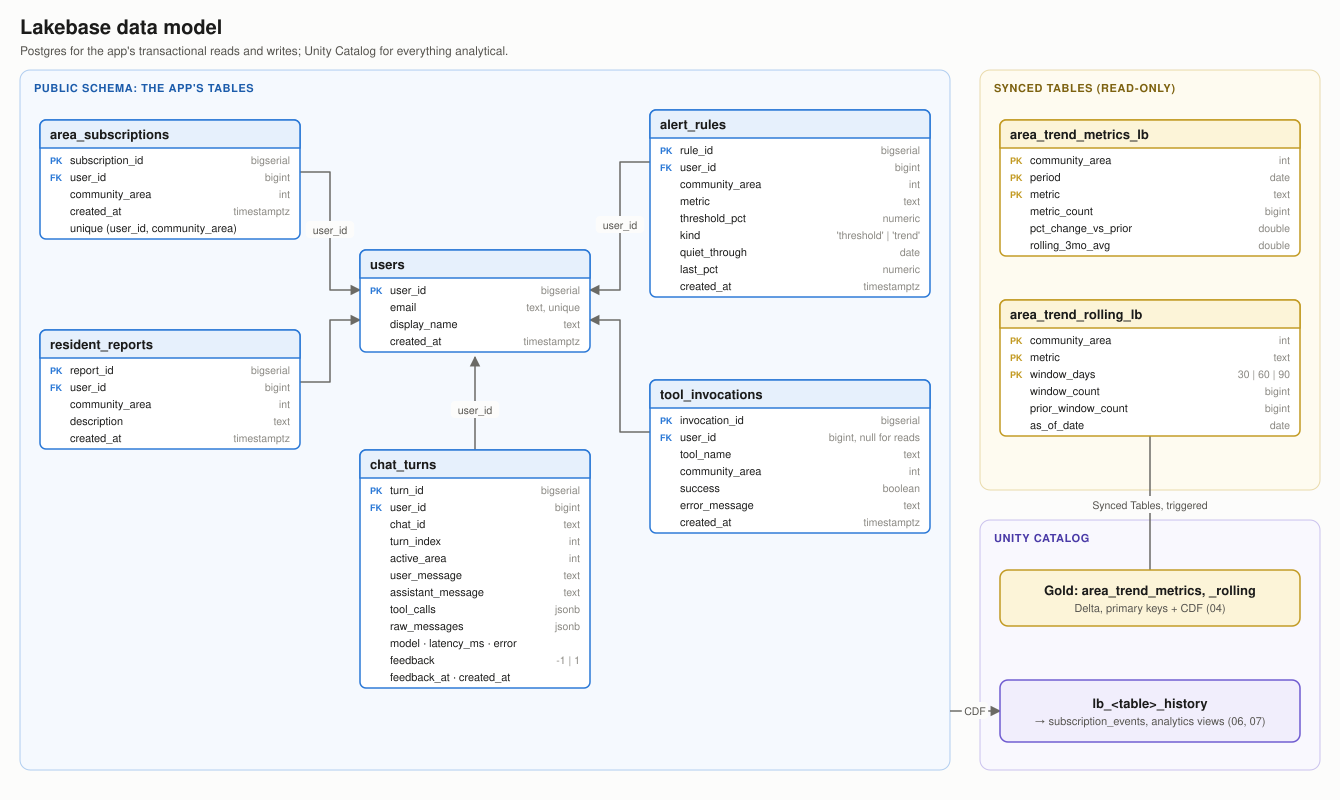

tables in lakebase/schema.sql: ['users', 'area_subscriptions', 'resident_reports', 'alert_rules', 'tool_invocations', 'chat_turns']


In [7]:
display(SVG(filename=str(ROOT / "docs/architecture/lakebase-model.svg")))
schema = (ROOT / "lakebase/schema.sql").read_text()
print("tables in lakebase/schema.sql:", re.findall(r"CREATE TABLE (\w+)", schema))

## The agent

One chat turn is a plain loop: send the conversation and the tool specs to the model, run whatever
tools it asks for, append the results, and repeat until it answers. There are ten tools, eight reads
and two writes, each an ordinary function. Tutorial 07 runs the real loop against fake data.

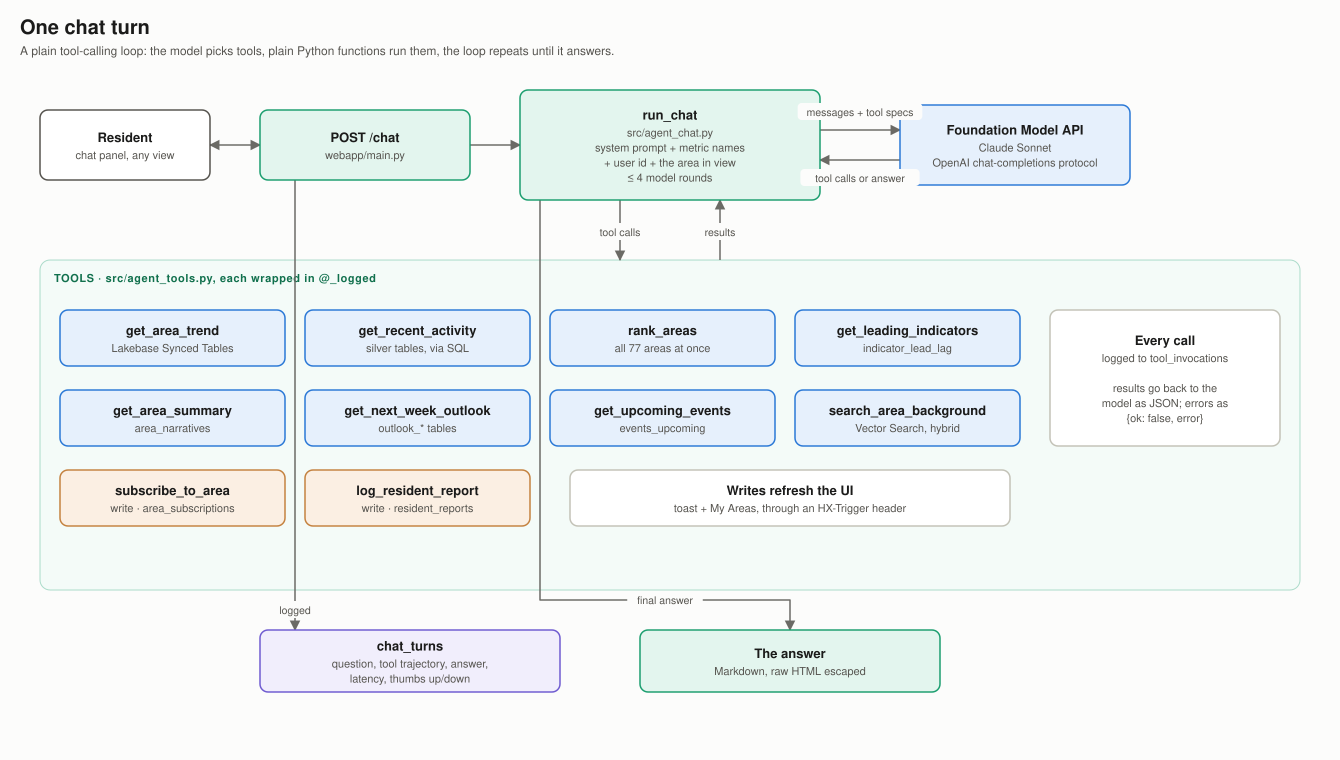

tool,what the model is told
get_area_trend,Current crime/311 trend scores for a Chicago community area: monthly history for charting the shape over time;...
rank_areas,"Rank all 77 community areas on one metric in a single call: trailing-window change, vs. normal for this time o..."
get_leading_indicators,Which 311 service-request types have historically risen 1-3 months BEFORE specific crime categories in the sam...
get_area_summary,A short plain-language summary of what's been happening in a community area lately (recent crime and 311 patte...
get_next_week_outlook,This week's crime forecast: whether a community area is likely to come in above or below its normal for this t...
get_upcoming_events,"Street festivals (from filed city permits) and club nights (ticketed shows at 20 small music clubs) coming up,..."
search_area_background,"Search Wikipedia background on Chicago's community areas: history, the neighborhoods inside each area, landmar..."
get_recent_activity,Recent individual crime and 311 records for a Chicago community area....
subscribe_to_area,Subscribe a user to trend updates for a community area. Idempotent....
log_resident_report,File a resident concern report for a community area....


In [8]:
display(SVG(filename=str(ROOT / "docs/architecture/agent-loop.svg")))
from src import agent_chat

pd.DataFrame([{"tool": s["function"]["name"], "what the model is told": s["function"]["description"][:110] + "..."}
              for s in agent_chat.TOOL_SPECS]).style.hide(axis="index")

## Next

[02 · Ingestion and the medallion layers](02_ingestion_and_medallion.ipynb) starts at the left edge
of the diagram: pulling from the city's API.